In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def f(y, dt):
    dx = y[2] * dt
    dy = y[3] * dt
    dvx = 0
    dvy = -g * dt

    return np.array([dx, dy, dvx, dvy])

In [3]:
def Euler(y):
    return y + f(y, dt)

In [11]:
g = 9.81
t = 0.0
dt = 0.01

v0 = 10
alpha = 1
vx = v0 * np.cos(alpha)
vy = v0 * np.sin(alpha)
y = np.array([0, 0, vx, vy])

T = [t]
Y_state_vector = [y]
X = [y[0]]
Y = [y[1]]
VX = [y[2]]
VY = [y[3]]

In [12]:
while Y[-1] >= 0:
    y = Euler(y)
    T.append(T[-1] + dt)
    Y_state_vector.append(y)
    X.append(y[0])
    Y.append(y[1])
    VX.append(y[2])
    VY.append(y[3])

In [24]:
dt_prime = dt * Y[-2] / (Y[-2] - Y[-1])
y_corrected = np.array([X[-2], Y[-2], VX[-2], VY[-2]])
y_corrected = y_corrected + f(y_corrected, dt_prime)

Y_state_vector[-1] = y_corrected
X[-1] = y_corrected[0]
Y[-1] = y_corrected[1]
VX[-1] = y_corrected[2]
VY[-1] = y_corrected[3]
T[-1] = T[-2] + dt_prime

Text(0.5, 1.0, 'y-koordináta az idő függvényében')

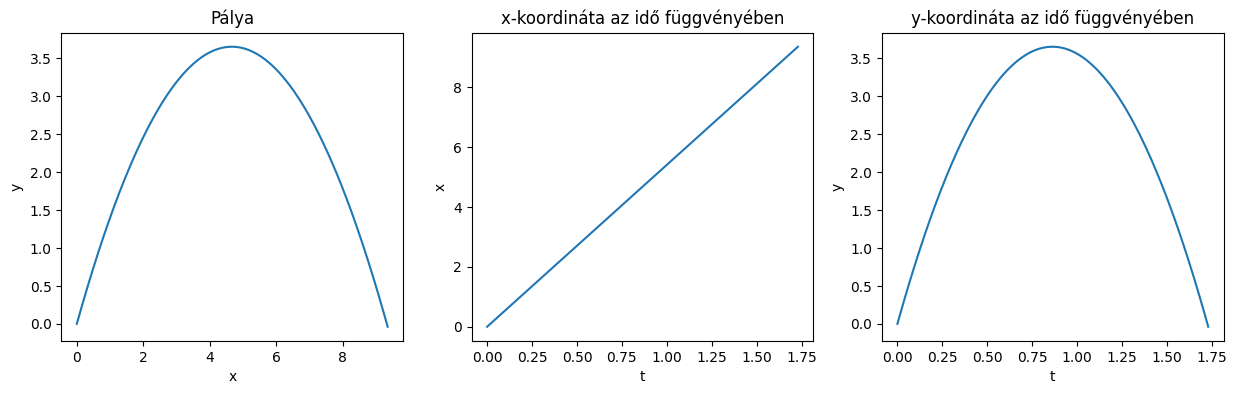

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(X, Y)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Pálya")

axes[1].plot(T, X)
axes[1].set_xlabel("t")
axes[1].set_ylabel("x")
axes[1].set_title("x-koordináta az idő függvényében")

axes[2].plot(T, Y)
axes[2].set_xlabel("t")
axes[2].set_ylabel("y")
axes[2].set_title("y-koordináta az idő függvényében")